# EDA: Реєстр платників ПДВ України

**Опис:** первинний огляд та підготовка даних реєстру платників ПДВ (Open Data).

**Мета:** перевірити структуру, якість даних і підготувати базову візуалізацію для подальшого аналізу.

## Імпорти
Стандартні бібліотеки для аналізу та візуалізації.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Конфігурація
Налаштування відображення та стилю графіків.

In [3]:
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

## Завантаження даних
Читаємо CSV з обробкою кодування та помилкових рядків.

In [4]:
data_path = Path("..") / "data" / "raw" / "pdv_actual_28-08-2019.csv"

df = pd.read_csv(
    data_path,
    sep=";",
    encoding="utf-8",
    on_bad_lines="skip",
)

df["dat_term"] = df["dat_term"].replace("null", pd.NA)
df["dat_reestr"] = pd.to_datetime(df["dat_reestr"], format="%d.%m.%Y", errors="coerce")

## Базовий огляд
Швидко перевіряємо перші рядки, типи полів та пропуски.

In [5]:
print("Data head:")
df.head()

Data head:


,name,kod_pdv,dat_reestr,dat_term
0,ТОВАРИСТВО З ОБМЕЖЕНОЮ ВІДПОВІДАЛЬНІСТЮ ЗОНТА-...,356383613199,2011-06-01,NaN
1,ТОВАРИСТВО З ОБМЕЖЕНОЮ ВІДПОВІДАЛЬНІСТЮ `ЗОЛОЧ...,337643613199,2005-11-24,NaN
2,ТОВАРИСТВО З ОБМЕЖЕНОЮ ВIДПОВIДАЛЬНIСТЮ ЛІВС А...,342753223040,2006-12-22,NaN
3,"ПРИВАТНЕ ПIДПРИЄМСТВО ЕНЕРГО-ІНВЕСТ""""",320265706190,2002-09-26,NaN
4,ТОВАРИСТВО З ОБМЕЖЕНОЮ ВIДПОВIДАЛЬНIСТЮ СК ТРЕ...,372635220232,2010-10-05,NaN


In [6]:
print("Data info:")
df.info()

print("\nData missing values:")
df.isnull().sum()

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 281074 entries, 0 to 281073
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   name        281074 non-null  str           
 1   kod_pdv     281074 non-null  str           
 2   dat_reestr  281021 non-null  datetime64[us]
 3   dat_term    555 non-null     str           
dtypes: datetime64[us](1), str(3)
memory usage: 8.6 MB

Data missing values:


name               0
kod_pdv            0
dat_reestr        53
dat_term      280519
dtype: int64

## Візуалізація
Приклад: кількість реєстрацій за роками.

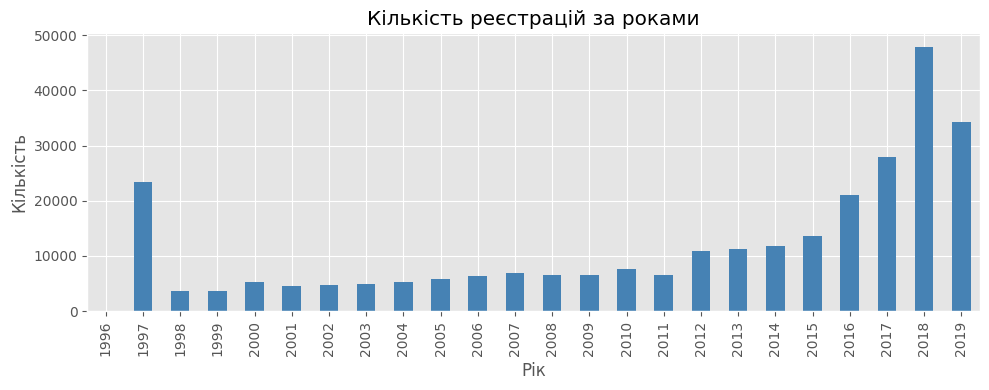

In [7]:
registrations_by_year = (
    df.dropna(subset=["dat_reestr"])
    .assign(year=lambda x: x["dat_reestr"].dt.year)
    .groupby("year")
    .size()
    .sort_index()
 )

plt.figure(figsize=(10, 4))
registrations_by_year.plot(kind="bar", color="steelblue")
plt.title("Кiлькiсть реєстрацiй за роками")
plt.xlabel("Рiк")
plt.ylabel("Кiлькiсть")
plt.tight_layout()
plt.show()

## Гіпотеза 1: Сезонність реєстрацій

**Припущення:** Реєстрація нових платників ПДВ має чітко виражену сезонність із піками на початку кожного кварталу (січень, квітень, липень, жовтень).

Реєстрації за місяцями:
month
1     24822
2     17666
3     20628
4     26494
5     20334
6     20134
7     38390
8     21672
9     24788
10    25360
11    20197
12    20536
dtype: int64


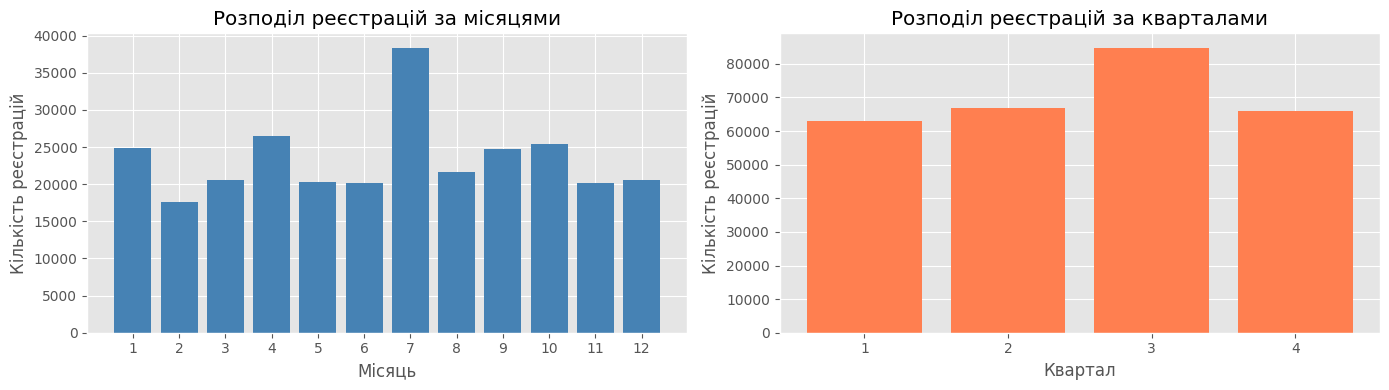


Аналіз гіпотези:
Очікування: піки на початку кварталів (січень, квітень, липень, жовтень - місяці 1, 4, 7, 10)
Реальність: найвищий місяць - 7 (місяцевих реєстрацій: 38390)
Найнижчий місяць - 2 (місяцевих реєстрацій: 17666)


In [8]:
df_with_dates = df.dropna(subset=["dat_reestr"]).copy()
df_with_dates["month"] = df_with_dates["dat_reestr"].dt.month
df_with_dates["quarter"] = df_with_dates["dat_reestr"].dt.quarter

registrations_by_month = df_with_dates.groupby("month").size()

print("Реєстрації за місяцями:")
print(registrations_by_month)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(registrations_by_month.index, registrations_by_month.values, color="steelblue")
axes[0].set_xlabel("Місяць")
axes[0].set_ylabel("Кількість реєстрацій")
axes[0].set_title("Розподіл реєстрацій за місяцями")
axes[0].set_xticks(range(1, 13))

registrations_by_quarter = df_with_dates.groupby("quarter").size()
axes[1].bar(registrations_by_quarter.index, registrations_by_quarter.values, color="coral")
axes[1].set_xlabel("Квартал")
axes[1].set_ylabel("Кількість реєстрацій")
axes[1].set_title("Розподіл реєстрацій за кварталами")
axes[1].set_xticks(range(1, 5))

plt.tight_layout()
plt.show()

print("\nАналіз гіпотези:")
print("Очікування: піки на початку кварталів (січень, квітень, липень, жовтень - місяці 1, 4, 7, 10)")
print(f"Реальність: найвищий місяць - {registrations_by_month.idxmax()} (місяцевих реєстрацій: {registrations_by_month.max()})")
print(f"Найнижчий місяць - {registrations_by_month.idxmin()} (місяцевих реєстрацій: {registrations_by_month.min()})")
